# Cross-section completeness and arrival-selection susceptibility of OSAP predictors

**An example notebook for `open-asset-pricing-download` (PyPI: `openassetpricing`).**

Every predictor in the Chen–Zimmermann Open Source Asset Pricing (OSAP) dataset is a
*cross-sectional* signal: it is only meaningful relative to the other firms measured in the
same period. But the firms in a cross-section do not report on the same day. If a signal is
computed before the last firm in the cross-section has reported, it is estimated from an
**incomplete** cross-section — and if reporting timing is related to the very disturbance the
signal measures (a firm with an unusual accrual is slower to file), the incompleteness is
*selective* and the signal carries a systematic bias. I call this **incomplete-cross-section
leakage**. It is distinct from ordinary look-ahead bias: no future data is used, and a
point-in-time join will not catch it, because every value used was genuinely available at the
timestamp it carries.

This notebook does three things with the OSAP API, end to end:

1. **Measures per-period cross-section completeness** for a handful of predictors — what
   fraction of each annual cross-section has actually refreshed by each calendar month.
2. **Runs the susceptibility screen** — a single statistic
   $\hat\rho = \mathrm{pcorr}(\text{arrival latency},\ \text{complete-cross-section residual}\mid x)$
   estimated *honestly* (fitted only on prior **completed** cycles, then frozen and applied to a
   held-out cycle) — and flags predictors whose $|\hat\rho|$ exceeds a threshold.
3. **Applies the release gate** — turning $\hat\rho$ into a per-predictor *required completeness*,
   so benign predictors release early and susceptible ones wait.

A **planted-truth positive control** is included so you can verify the screen actually has power
before you trust its verdict on real data.

**Headline result, stated up front:** on the OSAP panel *as shipped*, the predictors screened
here come out **benign**. That is a feature of the dataset, not a null result — OSAP's uniform
annual (June) and quarterly update convention already enforces a near-complete cross-section
before a value is published. The screen matters for OSAP *users* who rebuild predictors from
as-filed / point-in-time Compustat, where that uniform lag is replaced by real filing dates.
The last section says what OSAP could ship to let users check this directly.

---

### Method and citations

The measurement, the screen, and the release controller are developed in three publicly
available papers. Please cite them if you use this notebook:

1. Wu, K.-T., & Wu, K.-I. — *Correct-by-Construction Factor Computation: A Verifiably Point-in-Time Engine for
   Tradeable Signals.* [doi:10.6084/m9.figshare.32952482](https://doi.org/10.6084/m9.figshare.32952482)
2. Wu, K.-T., & Wu, K.-I. — *Measuring Incomplete-Cross-Section Leakage: A Matched Placebo, a Susceptibility
   Screen, and Evidence from Taiwan and US As-Filed Data.*
   [doi:10.6084/m9.figshare.33061955](https://doi.org/10.6084/m9.figshare.33061955)
3. Wu, K.-T., & Wu, K.-I. — *Susceptibility-Graded Release Control: Preventing Incomplete-Cross-Section Leakage
   in Financial Machine-Learning Pipelines without a Blanket Timeliness Penalty.*
   [doi:10.6084/m9.figshare.33158615](https://doi.org/10.6084/m9.figshare.33158615)

Paper 2 defines $\hat\rho$ and the matched-placebo design; paper 3 defines the release
controller used in section 5. The reference implementation is the MIT-licensed `pit-release-gate`
package (https://github.com/MaxWellApexLab/pit-release-gate), which this notebook imports if it is available and otherwise inlines, so
the notebook is self-contained either way. Both paths produce identical numbers.

**Data:** everything below runs on the free public OSAP release fetched through
`open-asset-pricing-download`. No WRDS account, no licensed data, no proprietary inputs.

*Author:* Kuan-Ta Wu, Max Well Apex LLC (New York, NY) — `maxwellapexlab@proton.me`.
*Notebook licence:* MIT, same as the OSAP tooling it is written for.

## 0. Setup

Dependencies: `numpy`, `pandas`, `scipy`, and `openassetpricing` (the PyPI distribution name of
`open-asset-pricing-download`). `matplotlib` is optional (one plot is skipped without it).

```bash
pip install openassetpricing numpy pandas scipy matplotlib
```

In [1]:
from __future__ import annotations

import os
import sys
import warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from scipy.stats import rankdata

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# ---- configuration -------------------------------------------------------
PREDICTORS      = ["Accruals", "AssetGrowth", "BM"]   # 3 accounting predictors
START_YYYYMM    = 200401        # panel start (needs one year of warm-up before FIRST_CYCLE)
FIRST_CYCLE     = 2005          # first annual cycle we build a cross-section for
TRAILING_K      = 5             # prior COMPLETED cycles used to fit rho-hat
EVAL_CYCLES     = 6             # most recent cycles that get gated with the frozen estimate
MIN_ENTITIES    = 200           # skip a cycle with fewer firms than this
RHO_THRESHOLD   = 0.10          # |rho-hat| above this => flag as susceptible
CACHE_PATH      = os.path.join("data", "osap_signal_panel_cache.csv.gz")

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.2.6 | pandas 2.2.3


## 1. The screen

The screen is one statistic. For a completed cross-section (one fiscal period, one group of
firms) let

* $a_i$ = the entity's **filing-arrival latency**, rank-normalised into $(0, 1]$, where $1$ is the
  statutory deadline;
* $u_i$ = the **complete-cross-section residual** — the predictor value with the construction
  regressors projected out, computed on the *whole* cross-section, so it is only available
  ex post;
* $x_i$ = the observable composition driver (size, or any characteristic known for every firm
  before the cycle opens).

Then

$$\hat\rho \;=\; \operatorname{corr}\big(\,a_i \perp x_i,\; u_i \perp x_i \,\big)$$

— the partial correlation of arrival latency with the disturbance, conditioning out the
observable. Conditioning on $x$ is what separates the two kinds of incompleteness:

* **Benign incompleteness (composition).** Big firms file first. The arrived subset is
  unrepresentative *on an observable*, which shifts composition but does not bias an estimator
  that already controls for that observable. $\hat\rho \approx 0$.
* **Malignant incompleteness (selection on the disturbance).** Firms whose residual is unusual
  file late. The arrived subset is unrepresentative *on the estimand itself*. No amount of
  reweighting on observables fixes this — only waiting for more of the cross-section does.
  $|\hat\rho|$ is large.

**Honest-estimation contract.** At release time the current period's cross-section is
incomplete, so $u_i$ for that period does not exist yet. $\hat\rho$ must therefore *never* be
computed on the period being gated. It is fitted on $K$ prior **completed** cycles, frozen, and
applied forward. The cell below enforces that contract; section 4 uses it.

The next cell imports `SusceptibilityGate` from the `pit-release-gate` package if it is
available, and otherwise inlines the same estimator (~80 lines) so the notebook is
self-contained.

In [2]:
# --------------------------------------------------------------------------
# Prefer the published reference implementation; fall back to an inline copy.
#   1. `pip install pit-release-gate`                          -> installed
#   2. set PIT_RELEASE_GATE_SRC to a source checkout's src/    -> checkout
#   3. neither                                                 -> inline below
# --------------------------------------------------------------------------
_SRC_CANDIDATES = [
    os.environ.get("PIT_RELEASE_GATE_SRC"),
    os.path.join("..", "..", "..", "..", "opensource", "pit-release-gate", "src"),
]

SCREEN_SOURCE = None
try:
    from pit_release_gate import (AsOfDataStore, CompletenessMonitor,
                                  ReleaseController, SusceptibilityGate)
    SCREEN_SOURCE = "pit_release_gate (installed)"
except ImportError:
    for _cand in _SRC_CANDIDATES:
        if _cand and os.path.isdir(_cand):
            sys.path.insert(0, os.path.abspath(_cand))
            break
    try:
        from pit_release_gate import (AsOfDataStore, CompletenessMonitor,
                                      ReleaseController, SusceptibilityGate)
        SCREEN_SOURCE = "pit_release_gate (source checkout)"
    except ImportError:
        SCREEN_SOURCE = "inline fallback"

if SCREEN_SOURCE == "inline fallback":
    # ---------------------------------------------------------------------
    # Inline estimator -- identical maths to pit_release_gate, no dependency.
    # Reference: doi:10.6084/m9.figshare.33061955 (screen),
    #            doi:10.6084/m9.figshare.33158615 (controller).
    # ---------------------------------------------------------------------
    @dataclass
    class AsOfDataStore:
        """Staggered-arrival records for ONE (period, group).

        X            (n, k) design matrix, column 0 = intercept, column 1 = size regressor
        y            (n,)   the construction-recipe value (the predictor)
        arrival      (n,)   filing-arrival time in (0, 1];  1.0 == statutory deadline
        size         (n,)   standardized observable composition driver
        truth_resid  (n,)   complete-cross-section residual (the estimand; ex post only)
        """
        X: np.ndarray
        y: np.ndarray
        arrival: np.ndarray
        size: np.ndarray
        truth_resid: np.ndarray = field(default=None)

        @property
        def n(self) -> int:
            return len(self.y)

        def arrived_mask(self, t: float) -> np.ndarray:
            """Entities whose filing has arrived by evaluation time t."""
            return self.arrival <= t

    class CompletenessMonitor:
        """Arrived-fraction and composition-shift gauges."""

        def fraction(self, store: "AsOfDataStore", t: float) -> float:
            return float(store.arrived_mask(t).mean())

        def covariate_shift(self, store: "AsOfDataStore", t: float) -> float:
            m = store.arrived_mask(t)
            if m.sum() < 2:
                return np.inf
            return abs(store.size[m].mean() - store.size.mean()) / (store.size.std() + 1e-9)

    class SusceptibilityGate:
        """rho_hat = partial corr(filing latency, complete residual | x).

        HONEST-ESTIMATION CONTRACT: rho_hat is NEVER computed from the period
        being gated. Fit on prior COMPLETED periods via fit_trailing(), then
        gate the live period with the frozen estimate.
        """

        def __init__(self, threshold: float = 0.10):
            self.threshold = threshold
            self.rho_trailing = None

        def _rho_one_period(self, store: "AsOfDataStore") -> float:
            u = store.truth_resid
            lat = rankdata(store.arrival) / store.n
            Xp = np.column_stack([np.ones(store.n), store.size])
            bl, *_ = np.linalg.lstsq(Xp, lat, rcond=None)
            rl = lat - Xp @ bl
            bu, *_ = np.linalg.lstsq(Xp, u, rcond=None)
            ru = u - Xp @ bu
            if rl.std() < 1e-9 or ru.std() < 1e-9:
                return 0.0
            return float(np.corrcoef(rl, ru)[0, 1])

        def fit_trailing(self, completed_periods: list) -> float:
            """Pool rho_hat over K prior COMPLETED periods; store for live gating."""
            self.rho_trailing = float(np.mean([self._rho_one_period(s) for s in completed_periods]))
            return self.rho_trailing

        def rho_hat(self, store: "AsOfDataStore") -> float:
            if self.rho_trailing is not None:
                return self.rho_trailing
            return self._rho_one_period(store)     # ORACLE: upper-bound analysis only

        def is_susceptible(self, rho: float) -> bool:
            return abs(rho) > self.threshold

    class ReleaseController:
        """Susceptibility-graded completeness gate: WITHHOLD until the arrived
        fraction reaches a per-signal required completeness set by rho_hat."""

        def __init__(self, phi_min=0.35, suscept_slope=1.0, gate=None, monitor=None, **_):
            self.phi_min = phi_min
            self.suscept_slope = suscept_slope
            self.gate = gate or SusceptibilityGate()
            self.monitor = monitor or CompletenessMonitor()

        def required_completeness(self, rho: float) -> float:
            """|rho_hat| ~ 0 -> release at phi_min; large |rho_hat| -> approach 1.0
            (wait for the deadline-complete cross-section). Only completeness
            suppresses selection-on-disturbance bias."""
            return float(min(1.0, self.phi_min + self.suscept_slope * abs(rho)))

print(f"susceptibility screen source: {SCREEN_SOURCE}")

susceptibility screen source: pit_release_gate (source checkout)


## 2. Pull predictors through the OSAP API

`OpenAP.dl_signal` returns the firm-month panel for named predictors — `permno`, `yyyymm`, one
column per predictor. Three accounting predictors are used here; the code is agnostic to which,
so edit `PREDICTORS` in section 0 and re-run.

The download is a few tens of seconds and requires no credentials. The cell caches the trimmed
panel to `data/` so the notebook can be re-run (and reviewed) offline; if the download fails for
any reason and a cache is present, it falls back to the cache and says so loudly. **The cache is
a local convenience, not part of the analysis** — delete it to force a fresh pull.

In [3]:
def load_panel(predictors, start_yyyymm, cache_path):
    """Fetch the OSAP firm-month panel for `predictors`, with an offline cache fallback.

    Returns (DataFrame[permno, yyyymm, <predictors>], provenance_string).
    """
    try:
        import openassetpricing as oap
        openap = oap.OpenAP()
        panel = openap.dl_signal("pandas", list(predictors))
        panel = panel.loc[panel["yyyymm"] >= start_yyyymm, ["permno", "yyyymm"] + list(predictors)]
        provenance = "LIVE download via open-asset-pricing-download (OpenAP.dl_signal)"
        os.makedirs(os.path.dirname(cache_path) or ".", exist_ok=True)
        panel.round(6).to_csv(cache_path, index=False, compression="gzip")
    except Exception as exc:                                     # noqa: BLE001
        if not os.path.exists(cache_path):
            raise RuntimeError(
                f"OSAP download failed ({exc!r}) and no cache at {cache_path}. "
                "Re-run with network access, or place a cached panel there."
            ) from exc
        # ============ OFFLINE FALLBACK -- NOT A LIVE DOWNLOAD ============
        print("!" * 78)
        print("!! OFFLINE FALLBACK: the OSAP download failed and the cached panel is being")
        print(f"!! used instead ({cache_path}). Reason: {exc!r}")
        print("!! Numbers below are computed on the cached copy of the same public OSAP data.")
        print("!" * 78)
        panel = pd.read_csv(cache_path)
        panel = panel.loc[panel["yyyymm"] >= start_yyyymm, ["permno", "yyyymm"] + list(predictors)]
        provenance = f"OFFLINE CACHE {cache_path}"
    return panel.reset_index(drop=True), provenance


panel, PROVENANCE = load_panel(PREDICTORS, START_YYYYMM, CACHE_PATH)
panel["year"] = panel["yyyymm"] // 100
panel["month"] = panel["yyyymm"] % 100

print(f"provenance : {PROVENANCE}")
print(f"rows       : {len(panel):,}")
print(f"period     : {panel['yyyymm'].min()} .. {panel['yyyymm'].max()}")
print(f"permnos    : {panel['permno'].nunique():,}")
print()
print(panel.head())


Data is downloaded: 25s


provenance : LIVE download via open-asset-pricing-download (OpenAP.dl_signal)
rows       : 1,340,368
period     : 200401 .. 202610
permnos    : 12,493

   permno  yyyymm  Accruals  AssetGrowth        BM  year  month
0   10001  200401  -0.07958     0.078902 -0.019289  2004      1
1   10001  200402  -0.07958     0.078902 -0.019289  2004      2
2   10001  200403  -0.07958     0.078902 -0.019289  2004      3
3   10001  200404  -0.07958     0.078902 -0.019289  2004      4
4   10001  200405  -0.07958     0.078902 -0.019289  2004      5


## 3. Per-period cross-section completeness

OSAP ships a *carry-forward* monthly panel: a firm's predictor value is repeated every month
until the next annual refresh. So the panel itself tells us when each firm's value actually
arrived — the first month of a cycle in which its value differs from the value it carried out of
the previous December.

That gives, for each predictor and each annual cycle, a genuine **arrival month** per firm, and
therefore a **completeness curve**: the fraction of the cycle's cross-section that has refreshed
by month $m$.

Two caveats, stated plainly because they bound everything that follows:

* This is *availability* staggering, not *filing* staggering. OSAP applies the conventional
  uniform annual lag, so most firms refresh in the same month; the residual spread comes from
  off-calendar fiscal year ends. It is a **lower bound** on the true as-filed staggering.
* A firm whose value is genuinely unchanged year over year is indistinguishable from one that
  never refreshed; those are assigned the deadline month, which is the conservative choice.

In [4]:
def cycle_table(panel, predictor):
    """One row per (permno, cycle-year): arrival month, cycle-end value, prior-cycle value.

    arrival month = first month of the cycle whose value differs from the value carried out
    of the previous December (i.e. the refresh); firms that never refresh are assigned the
    deadline month, 12.
    """
    d = panel[["permno", "year", "month", predictor]].dropna(subset=[predictor])
    wide = (d.pivot_table(index=["permno", "year"], columns="month",
                          values=predictor, aggfunc="last")
              .reindex(columns=range(1, 13)))
    wide = wide[wide.notna().all(axis=1)]                 # need all 12 months of the cycle
    prev_dec = wide[12].groupby(level=0).shift(1)         # previous cycle's closing value
    has_prev = prev_dec.notna().to_numpy()

    vals = wide.to_numpy()
    base = prev_dec.to_numpy()
    changed = ~np.isclose(vals, base[:, None], rtol=1e-6, atol=1e-12)
    arr_month = np.where(changed.any(axis=1), changed.argmax(axis=1) + 1, 12)

    out = pd.DataFrame({"arr_month": arr_month,
                        "value": vals[:, 11],             # cycle-end (complete) value
                        "lag_value": base},               # observable known before the cycle
                       index=wide.index)[has_prev]
    return out.reset_index().rename(columns={"year": "cycle"})


CYCLES = {p: cycle_table(panel, p) for p in PREDICTORS}
for p, tbl in CYCLES.items():
    print(f"{p:<14} {len(tbl):>8,} firm-cycles  |  cycles {tbl['cycle'].min()}-{tbl['cycle'].max()}")

Accruals         86,907 firm-cycles  |  cycles 2005-2025
AssetGrowth      87,017 firm-cycles  |  cycles 2005-2025
BM               55,402 firm-cycles  |  cycles 2005-2024


In [5]:
def completeness_curve(tbl, cycles=None):
    """Fraction of each cycle's cross-section that has refreshed by month m (m = 1..12)."""
    t = tbl if cycles is None else tbl[tbl["cycle"].isin(cycles)]
    rows = {}
    for cyc, g in t.groupby("cycle"):
        n = len(g)
        rows[cyc] = {m: float((g["arr_month"] <= m).sum()) / n for m in range(1, 13)}
    return pd.DataFrame(rows).T.rename_axis("cycle")


recent = sorted(CYCLES[PREDICTORS[0]]["cycle"].unique())[-EVAL_CYCLES:]
completeness = {p: completeness_curve(CYCLES[p]) for p in PREDICTORS}

summary = pd.DataFrame(
    {p: completeness[p].loc[completeness[p].index.isin(recent)].mean() for p in PREDICTORS}
).rename_axis("month by which arrived")
print(f"Mean cross-section completeness by calendar month (cycles {recent[0]}-{recent[-1]})\n")
print(summary.round(3).to_string(float_format=lambda v: f"{v:6.1%}"))

Mean cross-section completeness by calendar month (cycles 2020-2025)

                        Accruals  AssetGrowth     BM
month by which arrived                              
1                           1.1%         1.1%   3.7%
2                           1.8%         1.8%   4.7%
3                           6.0%         6.0%   8.7%
4                           7.0%         7.0%   9.7%
5                           7.4%         7.4%  10.0%
6                          88.2%        88.2%  87.0%
7                          90.9%        90.9%  90.2%
8                          91.4%        91.4%  90.7%
9                          94.9%        94.9%  93.8%
10                         95.7%        95.7%  94.8%
11                         96.4%        96.4%  95.6%
12                        100.0%       100.0% 100.0%


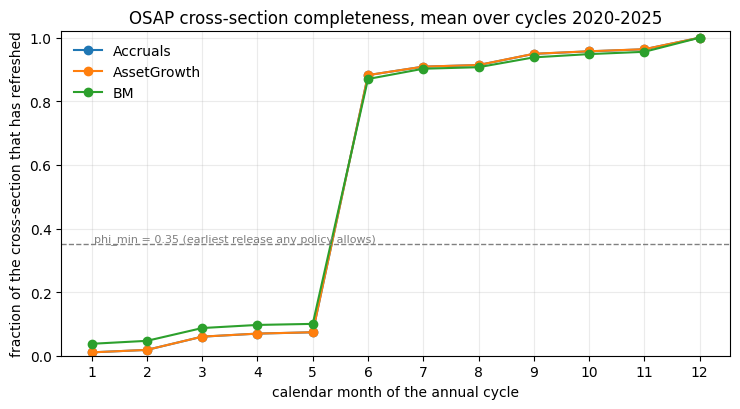

In [6]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib not installed - skipping the plot (all numbers are in the table above).")
else:
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    for p in PREDICTORS:
        ax.plot(summary.index, summary[p], marker="o", label=p)
    ax.axhline(0.35, ls="--", lw=1, color="grey")
    ax.text(1.05, 0.36, "phi_min = 0.35 (earliest release any policy allows)",
            fontsize=8, color="grey")
    ax.set_xlabel("calendar month of the annual cycle")
    ax.set_ylabel("fraction of the cross-section that has refreshed")
    ax.set_title(f"OSAP cross-section completeness, mean over cycles "
                 f"{recent[0]}-{recent[-1]}")
    ax.set_ylim(0, 1.02)
    ax.set_xticks(range(1, 13))
    ax.legend(loc="upper left", frameon=False)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

The curve is the point: the cross-section is **not** complete through the first half of the
cycle. Anything computed cross-sectionally before the step is computed on a partial population.
Whether that *matters* is exactly what the next section measures.

## 4. The susceptibility screen

For each predictor and each cycle we build one `AsOfDataStore`:

| field | what we use |
|---|---|
| `arrival` | refresh month / 12, so $1.0$ = the December deadline |
| `y` | the cycle-end (complete) predictor value, winsorised and standardised cross-sectionally |
| `size` | the **prior** cycle's closing value, standardised — an observable known to everyone before the cycle opens, so conditioning on it is legitimate |
| `X` | `[1, size]` |
| `truth_resid` | OLS residual of `y` on `X` over the **whole** cross-section — the estimand, available ex post only |

Then, for each evaluation cycle $Y$: fit $\hat\rho$ on cycles $Y-K \dots Y-1$ (completed, so their
residuals legitimately exist), **freeze it**, and use the frozen value to grade cycle $Y$. Nothing
from cycle $Y$ enters its own gate.

In [7]:
def _z(a, winsor=(1, 99)):
    """Winsorise at the given percentiles, then standardise."""
    a = np.asarray(a, dtype=float)
    lo, hi = np.nanpercentile(a, winsor)
    a = np.clip(a, lo, hi)
    return (a - a.mean()) / (a.std() + 1e-12)


def _ols_resid(X, y):
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ b


def build_stores(tbl, min_entities=MIN_ENTITIES):
    """One AsOfDataStore per cycle: {cycle -> store}."""
    stores = {}
    for cyc, g in tbl.groupby("cycle"):
        if len(g) < min_entities:
            continue
        n = len(g)
        size = _z(g["lag_value"].to_numpy())
        y = _z(g["value"].to_numpy())
        X = np.column_stack([np.ones(n), size])
        stores[int(cyc)] = AsOfDataStore(
            X=X, y=y,
            arrival=g["arr_month"].to_numpy(dtype=float) / 12.0,
            size=size,
            truth_resid=_ols_resid(X, y),
        )
    return stores


STORES = {p: build_stores(CYCLES[p]) for p in PREDICTORS}
for p, s in STORES.items():
    ks = sorted(s)
    print(f"{p:<14} {len(ks):>3} usable cycles ({ks[0]}-{ks[-1]}), "
          f"median n = {int(np.median([st.n for st in s.values()])):,}")

Accruals        21 usable cycles (2005-2025), median n = 4,043
AssetGrowth     21 usable cycles (2005-2025), median n = 4,044
BM              20 usable cycles (2005-2024), median n = 2,698


In [8]:
def screen(stores, trailing_k=TRAILING_K, eval_cycles=EVAL_CYCLES,
           threshold=RHO_THRESHOLD, phi_min=0.35, kappa=1.0):
    """Honest walk-forward screen.

    For each evaluation cycle Y: fit rho-hat on the `trailing_k` COMPLETED cycles before Y,
    freeze it, then grade Y. Returns one row per (predictor-cycle).
    """
    monitor = CompletenessMonitor()
    keys = sorted(stores)
    targets = [c for c in keys[trailing_k:]][-eval_cycles:]
    rows = []
    for cyc in targets:
        i = keys.index(cyc)
        train = [stores[k] for k in keys[i - trailing_k:i]]      # strictly prior, completed
        gate = SusceptibilityGate(threshold=threshold)
        rho = gate.fit_trailing(train)                            # <- frozen here
        live = stores[cyc]
        controller = ReleaseController(gate=gate, phi_min=phi_min, suscept_slope=kappa)
        phi_req = controller.required_completeness(rho)

        # earliest month at which the live cycle satisfies its required completeness
        months = np.arange(1, 13)
        comp = np.array([monitor.fraction(live, m / 12.0) for m in months])
        release_month = int(months[comp >= phi_req][0]) if (comp >= phi_req).any() else 12

        rows.append({
            "cycle": cyc,
            "n": live.n,
            "rho_hat (frozen)": rho,
            "susceptible": gate.is_susceptible(rho),
            "phi_req": phi_req,
            "release month": release_month,
            "completeness at release": float(comp[release_month - 1]),
            "rho realised (ex post)": gate._rho_one_period(live),   # reporting only
        })
    return pd.DataFrame(rows)


RESULTS = {p: screen(STORES[p]) for p in PREDICTORS}

for p in PREDICTORS:
    print(f"\n=== {p} " + "=" * (68 - len(p)))
    print(RESULTS[p].to_string(index=False,
          formatters={"rho_hat (frozen)": "{:+.4f}".format,
                      "rho realised (ex post)": "{:+.4f}".format,
                      "phi_req": "{:.2f}".format,
                      "completeness at release": "{:.1%}".format,
                      "n": "{:,}".format}))


=== Accruals ============================================================
 cycle     n rho_hat (frozen)  susceptible phi_req  release month completeness at release rho realised (ex post)
  2020 3,881          -0.0184        False    0.37              6                   87.2%                -0.0415
  2021 3,928          -0.0165        False    0.37              6                   87.6%                -0.0003
  2022 4,013          -0.0106        False    0.36              6                   87.7%                +0.0480
  2023 4,043          +0.0010        False    0.35              6                   87.7%                -0.0320
  2024 4,127          -0.0065        False    0.36              6                   87.4%                -0.0052
  2025 4,239          -0.0062        False    0.36              6                   91.9%                +0.0069

=== AssetGrowth =========================================================
 cycle     n rho_hat (frozen)  susceptible phi_req  release

In [9]:
verdict = pd.DataFrame([{
    "predictor": p,
    "mean rho_hat": RESULTS[p]["rho_hat (frozen)"].mean(),
    "max |rho_hat|": RESULTS[p]["rho_hat (frozen)"].abs().max(),
    "cycles flagged": int(RESULTS[p]["susceptible"].sum()),
    "cycles screened": len(RESULTS[p]),
    "mean phi_req": RESULTS[p]["phi_req"].mean(),
    "mean release month": RESULTS[p]["release month"].mean(),
} for p in PREDICTORS])
verdict["verdict"] = np.where(verdict["cycles flagged"] > 0, "SUSCEPTIBLE", "benign")

print(f"Susceptibility screen, threshold |rho_hat| > {RHO_THRESHOLD:.2f}\n")
print(verdict.to_string(index=False,
      formatters={"mean rho_hat": "{:+.4f}".format,
                  "max |rho_hat|": "{:.4f}".format,
                  "mean phi_req": "{:.2f}".format,
                  "mean release month": "{:.1f}".format}))

FLAGGED = verdict.loc[verdict["verdict"] == "SUSCEPTIBLE", "predictor"].tolist()
print()
if FLAGGED:
    print("FLAGGED -> do not release these on a partial cross-section: " + ", ".join(FLAGGED))
else:
    print("No predictor flagged: on the OSAP panel as shipped, arrival is not selected on the")
    print("disturbance, so early release does not introduce incomplete-cross-section bias.")
    print("See section 6 for why this is expected, and what it does and does not license.")

Susceptibility screen, threshold |rho_hat| > 0.10

  predictor mean rho_hat max |rho_hat|  cycles flagged  cycles screened mean phi_req mean release month verdict
   Accruals      -0.0096        0.0184               0                6         0.36                6.0  benign
AssetGrowth      -0.0062        0.0192               0                6         0.36                6.0  benign
         BM      +0.0203        0.0357               0                6         0.37                6.0  benign

No predictor flagged: on the OSAP panel as shipped, arrival is not selected on the
disturbance, so early release does not introduce incomplete-cross-section bias.
See section 6 for why this is expected, and what it does and does not license.


## 5. Positive control — does the screen actually fire?

A screen that never flags anything is worthless unless you have shown it *can* flag. So run it on
data where the answer is known by construction: cross-sections in which the strength of selection
on the disturbance is a knob we set ourselves.

`c_a` is that knob — the strength with which the disturbance $u$ drives filing order. `c_x` is
selection on the *observable* size regressor, which is the benign kind. A correct screen should
be near zero when `c_a = 0` **even when `c_x` is large**, and large when `c_a` is large.

In [10]:
def planted_cross_section(n=800, c_a=0.0, c_x=0.7, b=(0.0, 0.6, -0.4), rng=None):
    """One synthetic staggered-arrival cross-section with a PLANTED leakage strength.

    c_a = strength of selection ON the disturbance (the true leakage knob)
    c_x = strength of selection on the observable size regressor (benign composition shift)
    """
    rng = rng or np.random.default_rng(20260601)
    size = rng.standard_normal(n)
    x2 = rng.standard_normal(n)
    u = rng.standard_normal(n)                       # the disturbance == the estimand
    X = np.column_stack([np.ones(n), size, x2])
    y = b[0] + b[1] * size + b[2] * x2 + u
    lat_index = -(c_a * (u - u.mean()) / (u.std() + 1e-9)
                  + c_x * (size - size.mean()) / (size.std() + 1e-9)) \
                + 0.5 * rng.standard_normal(n)
    arrival = rankdata(lat_index) / n                # (0, 1]; 1.0 == deadline
    return AsOfDataStore(X=X, y=y, arrival=arrival, size=size,
                         truth_resid=_ols_resid(X, y))


CONTROLS = [
    ("clean          (c_a=0.0, c_x=0.3)", 0.0, 0.3, "benign"),
    ("composition    (c_a=0.0, c_x=2.0)", 0.0, 2.0, "benign"),
    ("mild leak      (c_a=0.3, c_x=0.7)", 0.3, 0.7, "SUSCEPTIBLE"),
    ("strong leak    (c_a=1.0, c_x=0.7)", 1.0, 0.7, "SUSCEPTIBLE"),
]

rng = np.random.default_rng(20260601)
rows = []
for label, c_a, c_x, expected in CONTROLS:
    gate = SusceptibilityGate(threshold=RHO_THRESHOLD)
    rho = gate.fit_trailing([planted_cross_section(c_a=c_a, c_x=c_x, rng=rng)
                             for _ in range(TRAILING_K)])
    got = "SUSCEPTIBLE" if gate.is_susceptible(rho) else "benign"
    rows.append({"planted case": label, "rho_hat": rho,
                 "phi_req": min(1.0, 0.35 + abs(rho)),
                 "screen says": got, "should say": expected, "correct": got == expected})

control = pd.DataFrame(rows)
print("Positive control: known planted truth\n")
print(control.to_string(index=False,
      formatters={"rho_hat": "{:+.3f}".format, "phi_req": "{:.2f}".format}))
print()
assert control["correct"].all(), "positive control FAILED - screen is miscalibrated"
print("All four planted cases classified correctly.")
print("Note the 'composition' row: selection is 2x stronger than the 'clean' row, but it acts")
print("entirely through an OBSERVABLE, so the screen correctly calls it benign and does not")
print("impose a timeliness penalty on it. That discrimination is the whole point of the screen -")
print("a raw completeness threshold would have withheld it.")

Positive control: known planted truth

                     planted case rho_hat phi_req screen says  should say  correct
clean          (c_a=0.0, c_x=0.3)  -0.011    0.36      benign      benign     True
composition    (c_a=0.0, c_x=2.0)  -0.015    0.37      benign      benign     True
mild leak      (c_a=0.3, c_x=0.7)  -0.461    0.81 SUSCEPTIBLE SUSCEPTIBLE     True
strong leak    (c_a=1.0, c_x=0.7)  -0.862    1.00 SUSCEPTIBLE SUSCEPTIBLE     True

All four planted cases classified correctly.
Note the 'composition' row: selection is 2x stronger than the 'clean' row, but it acts
entirely through an OBSERVABLE, so the screen correctly calls it benign and does not
impose a timeliness penalty on it. That discrimination is the whole point of the screen -
a raw completeness threshold would have withheld it.


## 6. Applying the gate: susceptibility-graded release

The screen produces a number; the controller turns it into a policy. The required completeness
for a signal is

$$\varphi_{\text{req}} = \min\!\big(1,\ \varphi_{\min} + \kappa\,|\hat\rho|\big)$$

so a benign signal releases at the floor $\varphi_{\min}$ (full timeliness) and a susceptible one
is withheld until enough of the cross-section has arrived to suppress the bias — up to the
statutory deadline. $\kappa$ is the timeliness–bias dial. The alternative policies are the two
corners you would otherwise be stuck choosing between: release immediately and eat the bias, or
wait for the deadline on *everything* and pay a blanket timeliness penalty on the benign
majority.

In [11]:
def gated_release(store, rho, phi_min=0.35, kappa=1.0):
    """Earliest month at which this cycle may be released under the graded gate."""
    monitor = CompletenessMonitor()
    phi_req = ReleaseController(phi_min=phi_min, suscept_slope=kappa).required_completeness(rho)
    for m in range(1, 13):
        if monitor.fraction(store, m / 12.0) >= phi_req:
            return m, phi_req
    return 12, phi_req


rng = np.random.default_rng(20260601)
monitor = CompletenessMonitor()
rows = []
for label, c_a, c_x, _ in CONTROLS:
    gate = SusceptibilityGate(threshold=RHO_THRESHOLD)
    rho = gate.fit_trailing([planted_cross_section(c_a=c_a, c_x=c_x, rng=rng)
                             for _ in range(TRAILING_K)])
    live = planted_cross_section(c_a=c_a, c_x=c_x, rng=rng)
    for kappa in (0.5, 1.0, 2.0):
        phi_req = ReleaseController(gate=gate, suscept_slope=kappa).required_completeness(rho)
        grid = np.linspace(0.05, 1.0, 20)
        rel = next((t for t in grid if monitor.fraction(live, t) >= phi_req), 1.0)
        rows.append({"planted case": label.split("(")[0].strip(), "kappa": kappa,
                     "rho_hat": rho, "phi_req": phi_req,
                     "released at completeness": monitor.fraction(live, rel)})

print("Timeliness-bias dial: how kappa moves the release point\n")
print(pd.DataFrame(rows).pivot(index="planted case", columns="kappa",
                               values="released at completeness")
      .reindex([c[0].split("(")[0].strip() for c in CONTROLS])
      .to_string(float_format=lambda v: f"{v:6.0%}"))
print("\nBenign rows sit at the floor for every kappa; susceptible rows climb toward the")
print("deadline as kappa rises. Only the susceptible signals pay for their own risk.")

Timeliness-bias dial: how kappa moves the release point

kappa           0.5    1.0    2.0
planted case                     
clean           40%    40%    40%
composition     40%    40%    45%
mild leak       60%    85%   100%
strong leak     80%   100%   100%

Benign rows sit at the floor for every kappa; susceptible rows climb toward the
deadline as kappa rises. Only the susceptible signals pay for their own risk.


In [12]:
# Now the same gate on the real OSAP cycles, using each predictor's frozen rho_hat.
rows = []
for p in PREDICTORS:
    res = RESULTS[p]
    for _, r in res.iterrows():
        store = STORES[p][int(r["cycle"])]
        for kappa in (0.5, 1.0, 2.0):
            m, phi_req = gated_release(store, r["rho_hat (frozen)"], kappa=kappa)
            rows.append({"predictor": p, "cycle": int(r["cycle"]), "kappa": kappa,
                         "release month": m})

osap_gate = (pd.DataFrame(rows)
             .pivot_table(index="predictor", columns="kappa", values="release month"))
print("Mean gated release month on real OSAP cycles (12 = wait for the deadline)\n")
print(osap_gate.to_string(float_format=lambda v: f"{v:5.1f}"))
print("\nFlat across kappa because rho_hat is near zero for all three predictors: the gate")
print("imposes no timeliness penalty where it cannot justify one. Read it carefully, though -")
print("month 6 is where OSAP's own update calendar puts the cross-section over the threshold")
print("(completeness jumps ~7% -> ~88% in June), so the binding constraint here is the")
print("dataset's uniform lag, not the gate. On an as-filed panel, where values appear as firms")
print("actually file, this table is where the gate would start doing work.")

Mean gated release month on real OSAP cycles (12 = wait for the deadline)

kappa         0.5   1.0   2.0
predictor                    
Accruals      6.0   6.0   6.0
AssetGrowth   6.0   6.0   6.0
BM            6.0   6.0   6.0

Flat across kappa because rho_hat is near zero for all three predictors: the gate
imposes no timeliness penalty where it cannot justify one. Read it carefully, though -
month 6 is where OSAP's own update calendar puts the cross-section over the threshold
(completeness jumps ~7% -> ~88% in June), so the binding constraint here is the
dataset's uniform lag, not the gate. On an as-filed panel, where values appear as firms
actually file, this table is where the gate would start doing work.


## 7. Cross-check against an independent replication audit

Separately from this notebook I have audited how far each OSAP predictor can be rebuilt outside
CRSP/Compustat, grading every predictor by how faithfully its economic content survives the
substitution. The three predictors screened above carry these grades:

| predictor | category | replication grade |
|---|---|---|
| `Accruals` | Accounting | low approximation |
| `AssetGrowth` | Accounting | close approximation |
| `BM` | Accounting | close approximation |

The two audits answer different questions and it is worth keeping them apart:

* the **replication grade** asks *can this predictor be rebuilt from other inputs at all* —
  a question about data availability and formula fidelity;
* the **susceptibility screen** asks *if you rebuild it from as-filed data, does releasing it on a
  partial cross-section bias it* — a question about arrival timing.

A predictor can be trivially replicable and highly susceptible, or the reverse. `Accruals` is the
interesting case: it grades only a *low* approximation outside Compustat (the accrual
decomposition needs balance-sheet items that most non-US vendors do not expose), which means
users rebuild it with substitutions — and rebuilt versions are exactly the ones that no longer
inherit OSAP's uniform update calendar.

In [13]:
audit = pd.DataFrame([
    {"predictor": "Accruals",    "category": "Accounting", "replication grade": "low_approximation"},
    {"predictor": "AssetGrowth", "category": "Accounting", "replication grade": "close_approximation"},
    {"predictor": "BM",          "category": "Accounting", "replication grade": "close_approximation"},
])
combined = (verdict[["predictor", "mean rho_hat", "max |rho_hat|", "verdict"]]
            .merge(audit, on="predictor", how="left")
            .rename(columns={"verdict": "susceptibility"}))
print(combined.to_string(index=False,
      formatters={"mean rho_hat": "{:+.4f}".format, "max |rho_hat|": "{:.4f}".format}))

  predictor mean rho_hat max |rho_hat| susceptibility   category   replication grade
   Accruals      -0.0096        0.0184         benign Accounting   low_approximation
AssetGrowth      -0.0062        0.0192         benign Accounting close_approximation
         BM      +0.0203        0.0357         benign Accounting close_approximation


## 8. Reading the result

**What the screen found.** On the OSAP panel as shipped, all three predictors are benign:
$|\hat\rho|$ sits an order of magnitude under the 0.10 threshold in every evaluation cycle
(mean $\hat\rho$ between $-0.010$ and $+0.020$), so the graded gate asks for barely more than the
floor — $\varphi_{\text{req}} \approx 0.36$ — and never binds. The observed release month is June
for all three, and that is OSAP's calendar rather than the gate's doing: completeness steps from
about 7% to about 88% in June, clearing any threshold the gate could plausibly set.

That is the correct answer, and it is a compliment to the dataset. OSAP applies the conventional
uniform annual lag before publishing an annual accounting predictor, so the cross-section is
already substantially complete at the moment a value first appears. A uniform lag is a blunt
instrument — it costs timeliness on every predictor, benign or not, which is exactly the blanket
penalty the graded gate exists to avoid — but it does close the arrival-selection channel, which
is what the screen measures.

**What it does not license.** The screen was run on *availability* staggering (fiscal-year-end
heterogeneity surviving the uniform lag), which is a lower bound on true *filing* staggering. The
moment a user rebuilds a predictor from as-filed / point-in-time Compustat — replacing the
uniform lag with real filing dates, which is what you want to do if you care about tradeability —
the uniform-lag protection is gone and $\hat\rho$ has to be re-estimated on the rebuilt panel.
Same for anyone porting a predictor to a market where the reporting calendar is more dispersed
than the US one. The notebook is written so that step is a one-line change: point `cycle_table`
at your own arrival timestamps and everything downstream runs unchanged.

**Limitations, honestly.**

* Three predictors, annual cycles, one arrival proxy. This is an example notebook, not a survey.
* The observable conditioner is the predictor's own prior-cycle value. A market-cap conditioner
  would be the natural choice, but OSAP's `Size` requires WRDS, and this notebook deliberately
  stays free-data-only. Users with WRDS should swap it in.
* Firms whose value is genuinely unchanged year over year are assigned the deadline month. That
  is conservative — it pushes measured completeness down, never up.

**One suggestion for the dataset.** The single change that would let users check this themselves
is an optional per-observation **arrival column** — the date the underlying filing became
available, alongside the `yyyymm` the value is stamped with. Everything in this notebook is
reconstruction work that would become unnecessary if that column existed, and it would let OSAP
users distinguish "this value is stamped 2020-06" from "this value was knowable on 2020-06".
I would be glad to help specify or implement it.

---

### Cite

* Wu, K.-T., & Wu, K.-I. *Correct-by-Construction Factor Computation: A Verifiably Point-in-Time Engine for
  Tradeable Signals.* [doi:10.6084/m9.figshare.32952482](https://doi.org/10.6084/m9.figshare.32952482)
* Wu, K.-T., & Wu, K.-I. *Measuring Incomplete-Cross-Section Leakage: A Matched Placebo, a Susceptibility
  Screen, and Evidence from Taiwan and US As-Filed Data.*
  [doi:10.6084/m9.figshare.33061955](https://doi.org/10.6084/m9.figshare.33061955)
* Wu, K.-T., & Wu, K.-I. *Susceptibility-Graded Release Control: Preventing Incomplete-Cross-Section Leakage in
  Financial Machine-Learning Pipelines without a Blanket Timeliness Penalty.*
  [doi:10.6084/m9.figshare.33158615](https://doi.org/10.6084/m9.figshare.33158615)

And, of course, the dataset itself: Chen, A. Y., & Zimmermann, T. *Open Source Cross-Sectional
Asset Pricing.* Critical Finance Review.

*Techniques shown here are the subject of pending U.S. patent applications; this notebook and the
`pit-release-gate` reference implementation are released under the MIT licence.*